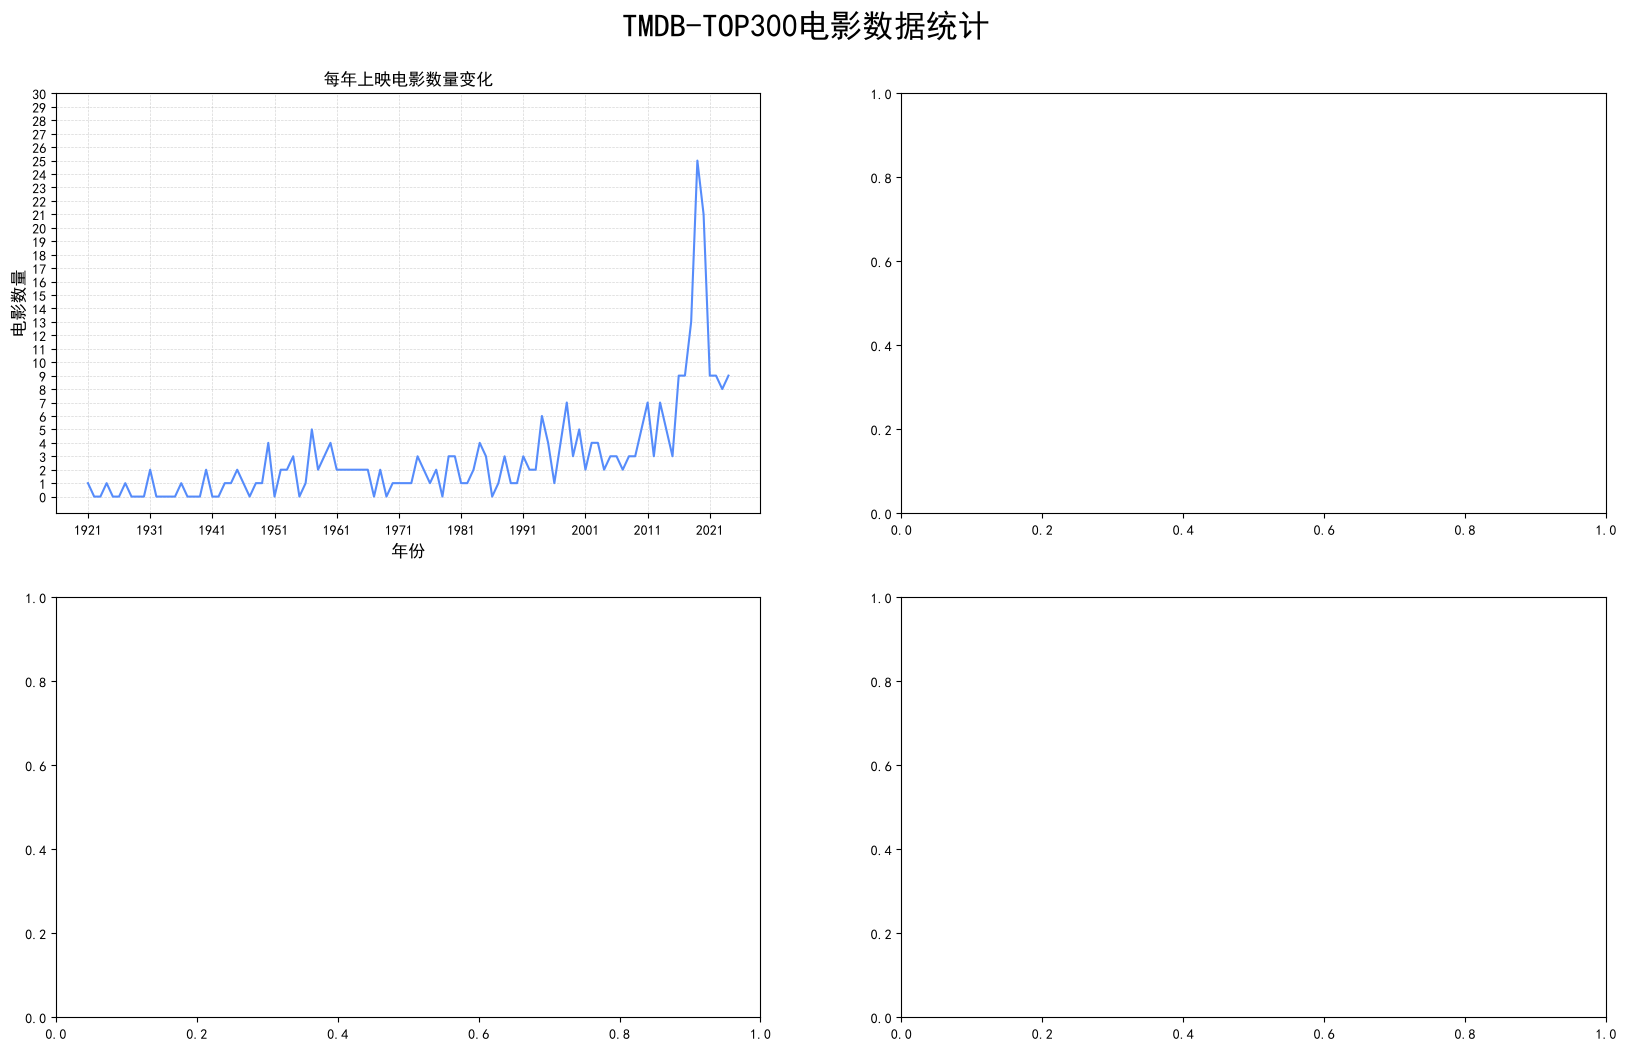

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.mpl_axes import Axes

#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

fig,ax = plt.subplots(nrows=2,ncols=2,figsize=(20,12),dpi=100)
fig.suptitle('TMDB-TOP300电影数据统计',fontsize=23,x=0.5,y=0.95)

axes1:Axes=ax[0][0]
axes2:Axes=ax[0][1]
axes3:Axes=ax[1][0]
axes4:Axes=ax[1][1]

#加载数据
data = pd.read_csv('data/movies.csv',usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':'Int64'})

data.isnull().sum()
data['年份']=data['年份'].fillna(data['上映时间'].str[0:4])
year_count = data.groupby('年份')['年份'].count()
#组装数据
min_year = year_count.index.min()
max_year = year_count.index.max()

x = [i for i in range(min_year,max_year)]

y = [year_count.get(i,0) for i in x]

axes1.plot(x,y)
axes1.set_title('每年上映电影数量变化')
axes1.set_xlabel('年份',fontsize = 12)
axes1.set_ylabel('电影数量',fontsize = 12)
axes1.set_xticks(x[::10])
y_ticks = [i for i in range(0,31)]
axes1.set_yticks(y_ticks)
axes1.grid(linestyle= '--',alpha=0.5)